In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch12_sft-lora"

data_dir = Path("data") / "ch12" / "sft-lora"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
133,5400,118,train,6.096,0.0001,2025-10-18T18:30:59%:z
142,5750,126,train,6.097,0.0001,2025-10-18T18:41:20%:z
136,5500,120,train,6.098,0.0001,2025-10-18T18:33:56%:z
140,5650,123,train,6.098,0.0001,2025-10-18T18:38:23%:z
143,5800,127,train,6.098,0.0001,2025-10-18T18:42:50%:z
137,5550,121,train,6.100,0.0001,2025-10-18T18:35:23%:z
138,5600,122,train,6.100,0.0001,2025-10-18T18:36:52%:z
141,5700,124,train,6.100,0.0001,2025-10-18T18:39:52%:z
130,5250,115,train,6.102,0.0001,2025-10-18T18:26:42%:z
123,5000,109,train,6.103,0.0001,2025-10-18T14:26:29%:z


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
132,5350,117,train,6.107,0.0001,2025-10-18T18:29:33%:z
133,5400,118,train,6.096,0.0001,2025-10-18T18:30:59%:z
135,5450,119,train,6.104,0.0001,2025-10-18T18:32:28%:z
136,5500,120,train,6.098,0.0001,2025-10-18T18:33:56%:z
137,5550,121,train,6.100,0.0001,2025-10-18T18:35:23%:z
138,5600,122,train,6.100,0.0001,2025-10-18T18:36:52%:z
140,5650,123,train,6.098,0.0001,2025-10-18T18:38:23%:z
141,5700,124,train,6.100,0.0001,2025-10-18T18:39:52%:z
142,5750,126,train,6.097,0.0001,2025-10-18T18:41:20%:z
143,5800,127,train,6.098,0.0001,2025-10-18T18:42:50%:z


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
99,4000,87,eval,6.819,NaN,2025-10-18T13:56:18%:z
104,4200,92,eval,6.819,NaN,2025-10-18T14:02:21%:z
109,4400,96,eval,6.817,NaN,2025-10-18T14:08:24%:z
114,4600,100,eval,6.818,NaN,2025-10-18T14:14:23%:z
119,4800,105,eval,6.816,NaN,2025-10-18T14:20:26%:z
124,5000,109,eval,6.816,NaN,2025-10-18T14:26:31%:z
129,5200,114,eval,6.815,NaN,2025-10-18T18:25:19%:z
134,5400,118,eval,6.815,NaN,2025-10-18T18:31:01%:z
139,5600,122,eval,6.814,NaN,2025-10-18T18:36:54%:z
144,5800,127,eval,6.815,NaN,2025-10-18T18:42:52%:z


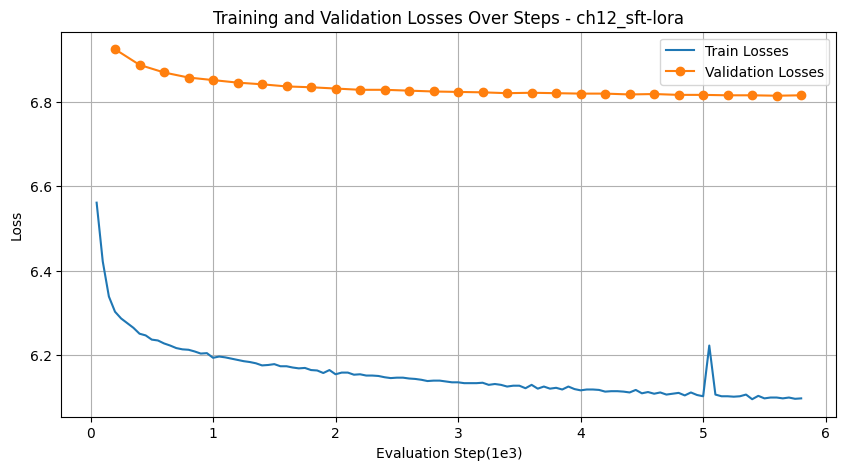

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

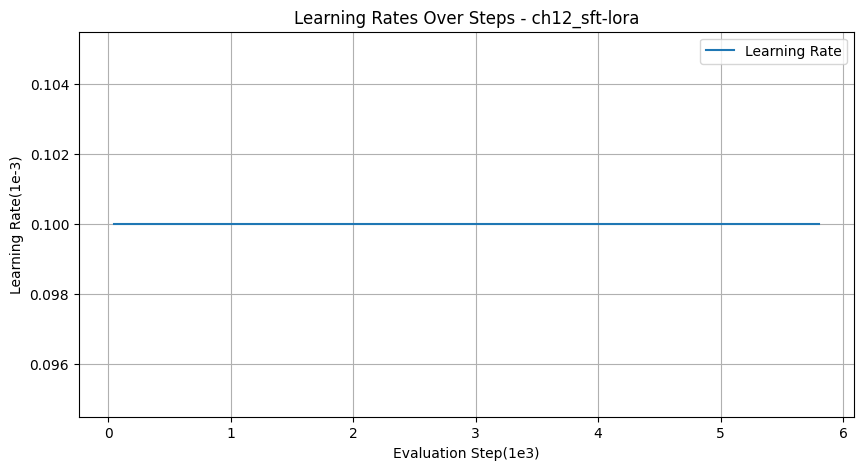

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")